In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 330M/330M [00:04<00:00, 69.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1


In [2]:
!mv /root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1 /content/face-mask-dataset


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [4]:
train_dir = "/content/face-mask-dataset/Face Mask Dataset/Train"
val_dir = "/content/face-mask-dataset/Face Mask Dataset/Validation"

img_size = 128
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)


Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, epochs=20, validation_data=val_data)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.8994 - loss: 0.2845 - val_accuracy: 0.9887 - val_loss: 0.0326
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9816 - loss: 0.0509 - val_accuracy: 0.9862 - val_loss: 0.0441
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9855 - loss: 0.0400 - val_accuracy: 0.9925 - val_loss: 0.0290
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.9874 - loss: 0.0333 - val_accuracy: 0.9850 - val_loss: 0.0319
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9918 - loss: 0.0229 - val_accuracy: 0.9937 - val_loss: 0.0184
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9925 - loss: 0.0215 - val_accuracy: 0.9925 - val_loss: 0.0246
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.9943 - loss: 0.0145 - val_accuracy: 0.9950 - val_loss: 0.0226
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.9954 - loss: 0.0135 - val_accurac

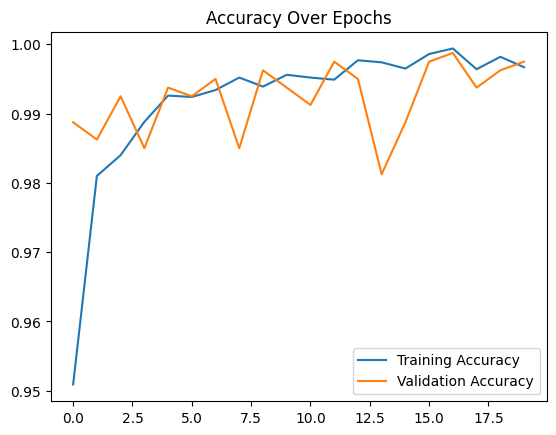

In [7]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.show()


In [8]:
model.save("face_mask_classifier.h5")


Found 992 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.9865 - loss: 0.0657

Test Accuracy: 0.98
Test Loss: 0.0937
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step

Classification Report:

              precision    recall  f1-score   support

    WithMask       0.98      0.99      0.98       483
 WithoutMask       0.99      0.98      0.98       509

    accuracy                           0.98       992
   macro avg       0.98      0.98      0.98       992
weighted avg       0.98      0.98      0.98       992



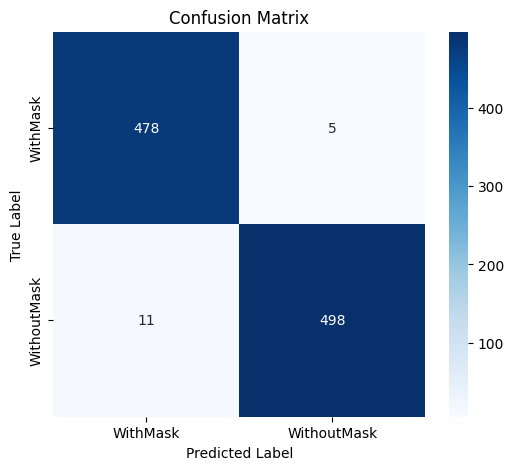

In [9]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Load your trained model
model = load_model("/content/face_mask_classifier.h5")

# Set test directory
test_dir = "/content/face-mask-dataset/Face Mask Dataset/Test"

# Image size and batch
img_size = 128
batch_size = 32

# Prepare test data generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Evaluate
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_acc:.2f}")
print(f"Test Loss: {test_loss:.4f}")

# Predict
predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype("int32").flatten()

# True labels
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Classification report
print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 994ms/step


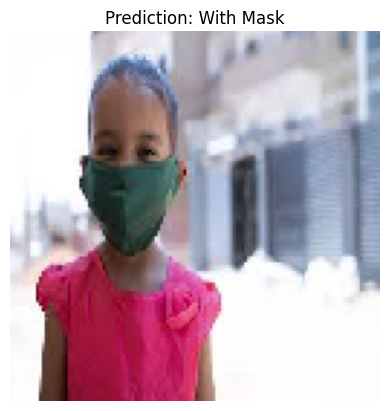

In [10]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load the trained model
model = load_model("/content/face_mask_classifier.h5")

# Path to your test image
img_path = "/content/download.jpeg"  # Change this to your image

# Load and preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize

# Predict
prediction = model.predict(img_array)
label = "With Mask" if prediction[0][0] < 0.5 else "Without Mask"

# Show image and result
plt.imshow(img)
plt.title(f"Prediction: {label}")
plt.axis("off")
plt.show()
